# TRABALHO FINAL INTEGRADOR - SEMANA 2
## Agrupamento de Dados I: representação, distância e baseline
### Cenário 4: Detecção de Fraude ou Transações Financeiras Suspeitas

---

**Disciplina:** Tópicos Especiais 2 - Agrupamento de Dados e Inteligência Computacional
**Responsável técnico:** Ruan (Agrupamento de Dados)
**Etapa:** Semana 2 de 5

---

## Objetivo da Semana
Construir um **baseline de agrupamento (clustering)** usando **K-Means** sobre a base
já tratada na Semana 1. A meta é agrupar transações por **similaridade** (sem usar a
coluna `Class`) e verificar se algum cluster concentra mais fraudes que a média global.

### Pergunta Central do Projeto
**Como usar agrupamento para identificar padrões normais e anômalos e apoiar um modelo
de detecção de fraude ou risco?**

> ⚠️ A coluna `Class` (fraude) **não** entra no treino do K-Means. Ela é usada apenas
> *depois* do agrupamento para avaliar a taxa de fraude por cluster.

---

## 1️⃣ CONTEXTO E PRÉ-REQUISITOS DA SEMANA 1

Partimos da base limpa da Semana 1:
- ~283.726 linhas (após remoção de duplicatas)
- 0 valores ausentes
- Outliers em `Amount` **mantidos** (podem ser fraudes)
- Desbalanceamento extremo: ~0,17% de fraudes

Features disponíveis: `V1`–`V28` (PCA) + `Time` + `Amount`. Alvo: `Class`.

## 2️⃣ IMPORTAÇÕES E CONFIGURAÇÕES

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Configurações visuais
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# Semente para reprodutibilidade
RANDOM_STATE = 42

print("✅ Ambiente configurado com sucesso!")

Matplotlib is building the font cache; this may take a moment.


✅ Ambiente configurado com sucesso!


## 3️⃣ CARREGAMENTO E PREPARAÇÃO DOS DADOS

Carregamos o CSV, repetimos a remoção de duplicatas da Semana 1 e separamos
as **features de clustering** do **alvo** (`Class`).

In [2]:
# Caminho robusto: funciona rodando da raiz do projeto ou da pasta notebooks/
DATA_PATH = 'dados/creditcard.csv' if os.path.exists('dados/creditcard.csv') else '../dados/creditcard.csv'

df = pd.read_csv(DATA_PATH)
print(f"Base bruta: {df.shape[0]:,} linhas x {df.shape[1]} colunas")

# Remoção de duplicatas (mesma decisão da Semana 1)
duplicadas = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicatas removidas: {duplicadas:,}")
print(f"Base final: {df.shape[0]:,} linhas")

# Separação features x alvo
feature_cols = [c for c in df.columns if c != 'Class']
X = df[feature_cols].copy()
y = df['Class'].copy()

print(f"\nFeatures usadas no clustering ({len(feature_cols)}): {feature_cols}")
print(f"Taxa global de fraude: {y.mean() * 100:.3f}%")

Base bruta: 284,807 linhas x 31 colunas


Duplicatas removidas: 1,081
Base final: 283,726 linhas

Features usadas no clustering (30): ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
Taxa global de fraude: 0.167%


## 4️⃣ NORMALIZAÇÃO / PADRONIZAÇÃO

O K-Means usa **distância euclidiana**, então a escala das variáveis importa muito.
`Amount` (até ~25.000) e `Time` (até ~172.000) têm escalas muito maiores que as
componentes PCA (`V1`–`V28`, ~média 0). Sem padronização, essas duas colunas
dominariam o cálculo de distância.

Usamos `StandardScaler` (média 0, desvio padrão 1) em **todas** as features.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape escalado: {X_scaled.shape}")
print(f"Média (~0):   {X_scaled.mean():.6f}")
print(f"Desvio (~1):  {X_scaled.std():.6f}")

Shape escalado: (283726, 30)
Média (~0):   0.000000
Desvio (~1):  1.000000


## 5️⃣ SELEÇÃO DE ATRIBUTOS

**Decisão (baseline):** usar todas as 30 features (`V1`–`V28` + `Time` + `Amount`).

Justificativa:
- `V1`–`V28` já são componentes PCA e carregam a maior parte do sinal.
- `Amount` é interpretável e relevante para risco financeiro.
- `Time` é mantido no baseline; em iterações futuras pode-se testar removê-lo.

Subconjuntos alternativos podem ser explorados na Semana 3 ao comparar algoritmos.

In [4]:
print("Atributos no baseline:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

Atributos no baseline:
   1. Time
   2. V1
   3. V2
   4. V3
   5. V4
   6. V5
   7. V6
   8. V7
   9. V8
  10. V9
  11. V10
  12. V11
  13. V12
  14. V13
  15. V14
  16. V15
  17. V16
  18. V17
  19. V18
  20. V19
  21. V20
  22. V21
  23. V22
  24. V23
  25. V24
  26. V25
  27. V26
  28. V27
  29. V28
  30. Amount


## 6️⃣ ESCOLHA DO NÚMERO DE CLUSTERS (k)

Combinamos dois critérios:
- **Método do cotovelo (elbow):** inércia (soma das distâncias ao centróide) vs. k.
- **Silhouette Score:** mede coesão x separação (quanto maior, melhor).

O silhouette é calculado em uma **amostra** (20.000 pontos), pois seu custo é O(n²) e ficaria inviável no dataset completo.

In [5]:
k_range = range(2, 11)
inertias = []
sil_scores = []

# Amostra estratificada simples para o silhouette (desempenho)
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(X_scaled.shape[0], size=20000, replace=False)
X_sample = X_scaled[sample_idx]

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=5)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_sample, km.predict(X_sample))
    sil_scores.append(sil)
    print(f"k={k:2d} | inércia={km.inertia_:14,.0f} | silhouette={sil:.4f}")

best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"\n👉 Melhor k pelo silhouette: {best_k}")

k= 2 | inércia=     8,117,496 | silhouette=0.0674


k= 3 | inércia=     7,840,854 | silhouette=0.0670


k= 4 | inércia=     7,613,247 | silhouette=0.0730


k= 5 | inércia=     7,405,722 | silhouette=0.0738


k= 6 | inércia=     7,197,503 | silhouette=0.0863


k= 7 | inércia=     7,062,088 | silhouette=0.0695


k= 8 | inércia=     6,950,250 | silhouette=0.0630


k= 9 | inércia=     6,742,788 | silhouette=0.0740


k=10 | inércia=     6,522,953 | silhouette=0.0748

👉 Melhor k pelo silhouette: 6


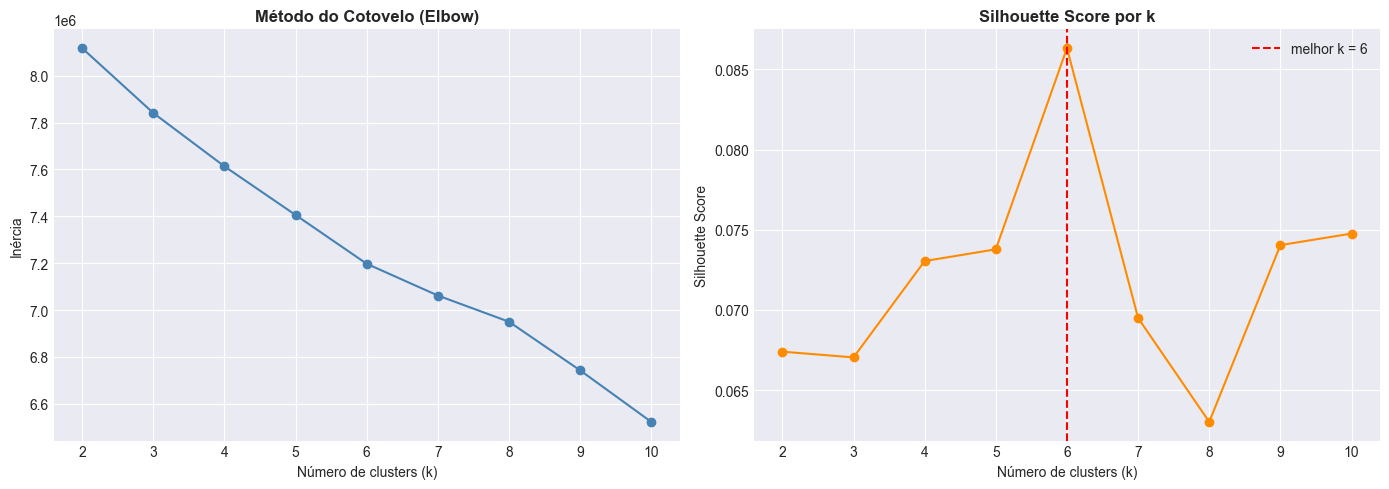

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, 'o-', color='steelblue')
axes[0].set_title('Método do Cotovelo (Elbow)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inércia')

axes[1].plot(list(k_range), sil_scores, 'o-', color='darkorange')
axes[1].axvline(best_k, color='red', linestyle='--', label=f'melhor k = {best_k}')
axes[1].set_title('Silhouette Score por k', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7️⃣ K-MEANS (BASELINE)

Treinamos o modelo final com o `k` escolhido e atribuímos um rótulo de cluster
a cada transação. Parâmetros: `n_init=10` e `random_state=42` (reprodutibilidade).

In [7]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means treinado com k={best_k}")
print(f"Inércia final: {kmeans.inertia_:,.0f}\n")
print("Transações por cluster:")
print(df['cluster'].value_counts().sort_index())

K-Means treinado com k=6
Inércia final: 7,197,503

Transações por cluster:
cluster
0     15716
1     86447
2    126518
3      4070
4     19641
5     31334
Name: count, dtype: int64


## 8️⃣ ANÁLISE INICIAL DOS CLUSTERS

O insight mais importante desta semana: **a taxa de fraude por cluster**.
Comparamos com a taxa global (~0,17%) para ver se algum grupo concentra anomalias.

In [8]:
analise = df.groupby('cluster').agg(
    transacoes=('Class', 'size'),
    fraudes=('Class', 'sum'),
    amount_medio=('Amount', 'mean'),
).reset_index()

analise['pct_transacoes'] = (analise['transacoes'] / len(df) * 100).round(2)
analise['taxa_fraude_%'] = (analise['fraudes'] / analise['transacoes'] * 100).round(3)

taxa_global = y.mean() * 100
analise['vs_global'] = (analise['taxa_fraude_%'] / taxa_global).round(1)

print(f"Taxa global de fraude: {taxa_global:.3f}%\n")
display(analise)

Taxa global de fraude: 0.167%



,cluster,transacoes,fraudes,amount_medio,pct_transacoes,taxa_fraude_%,vs_global
0,0,15716,0,60.8127,5.5400,0.0000,0.0000
1,1,86447,31,72.3191,30.4700,0.0360,0.2000
2,2,126518,156,73.4888,44.5900,0.1230,0.7000
3,3,4070,10,1549.7923,1.4300,0.2460,1.5000
4,4,19641,73,52.1956,6.9200,0.3720,2.2000
5,5,31334,203,40.3400,11.0400,0.6480,3.9000


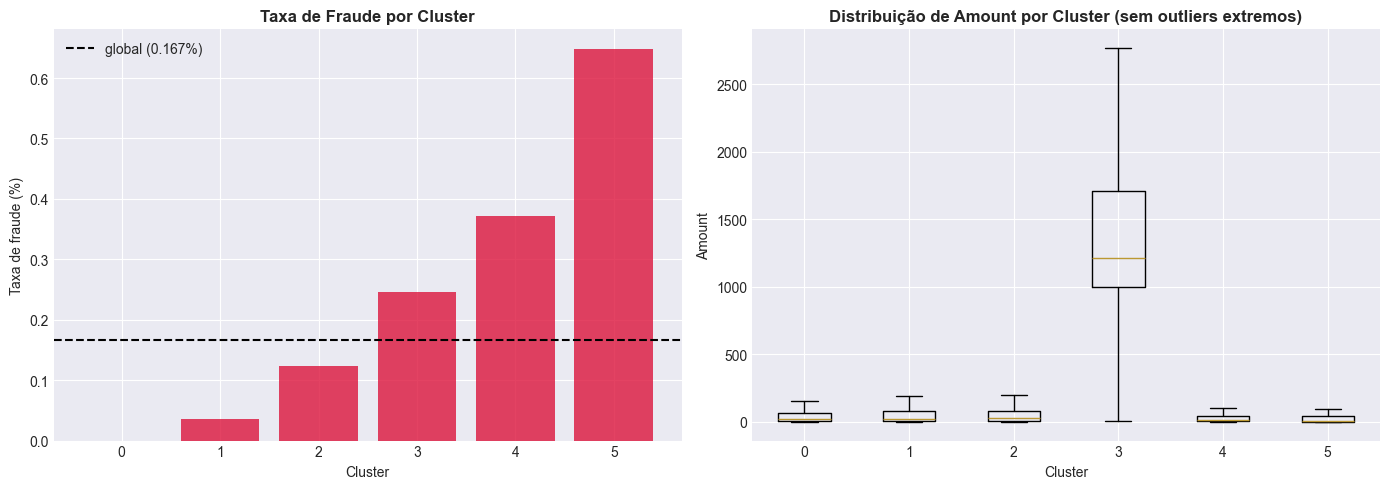

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taxa de fraude por cluster
axes[0].bar(analise['cluster'].astype(str), analise['taxa_fraude_%'], color='crimson', alpha=0.8)
axes[0].axhline(taxa_global, color='black', linestyle='--', label=f'global ({taxa_global:.3f}%)')
axes[0].set_title('Taxa de Fraude por Cluster', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Taxa de fraude (%)')
axes[0].legend()

# Distribuição de Amount por cluster (escala log para visualização)
data_amount = [df[df['cluster'] == c]['Amount'] for c in sorted(df['cluster'].unique())]
axes[1].boxplot(data_amount, tick_labels=[str(c) for c in sorted(df['cluster'].unique())], showfliers=False)
axes[1].set_title('Distribuição de Amount por Cluster (sem outliers extremos)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Amount')

plt.tight_layout()
plt.show()

## 9️⃣ VALIDAÇÃO PRELIMINAR

Calculamos o Silhouette Score do modelo final (na amostra) e comentamos as
limitações do K-Means para este problema.

In [10]:
sil_final = silhouette_score(X_sample, kmeans.predict(X_sample))
print(f"Silhouette Score (k={best_k}, amostra de {len(X_sample):,}): {sil_final:.4f}")

print("\nInterpretação rápida:")
print("  ~1.0  -> clusters bem separados e coesos")
print("  ~0.0  -> clusters sobrepostos / fronteiras ambíguas")
print("  < 0   -> pontos provavelmente no cluster errado")

print("\nLimitações do K-Means neste cenário:")
print("  - Assume clusters esféricos e de tamanho semelhante")
print("  - Sensível à escolha de k e à inicialização")
print("  - Fraudes são raras (0,17%): podem se dissolver em clusters grandes")
print("  - DBSCAN (Semana 3) tende a ser melhor para detectar anomalias")

Silhouette Score (k=6, amostra de 20,000): 0.0863

Interpretação rápida:
  ~1.0  -> clusters bem separados e coesos
  ~0.0  -> clusters sobrepostos / fronteiras ambíguas
  < 0   -> pontos provavelmente no cluster errado

Limitações do K-Means neste cenário:
  - Assume clusters esféricos e de tamanho semelhante
  - Sensível à escolha de k e à inicialização
  - Fraudes são raras (0,17%): podem se dissolver em clusters grandes
  - DBSCAN (Semana 3) tende a ser melhor para detectar anomalias


## 🔟 CONCLUSÃO E PRÓXIMAS ETAPAS

In [11]:
print("=" * 70)
print("RESUMO DA SEMANA 2 - CLUSTERING BASELINE (K-MEANS)")
print("=" * 70)

cluster_top = analise.loc[analise['taxa_fraude_%'].idxmax()]

print(f"\n✅ STATUS:")
print(f"   - Base usada: {len(df):,} transações")
print(f"   - Features normalizadas: {len(feature_cols)} (StandardScaler)")
print(f"   - k escolhido: {best_k} (maior silhouette)")
print(f"   - Silhouette final: {sil_final:.4f}")

print(f"\n📊 ACHADOS:")
print(f"   - Taxa global de fraude: {taxa_global:.3f}%")
print(f"   - Cluster com maior taxa de fraude: cluster {int(cluster_top['cluster'])}")
print(f"     -> {cluster_top['taxa_fraude_%']:.3f}% ({cluster_top['vs_global']}x a média global)")

print(f"\n🎯 PRÓXIMAS ETAPAS (SEMANA 3):")
print(f"   - Aplicar DBSCAN (melhor para anomalias/fraudes)")
print(f"   - Comparar K-Means vs DBSCAN")
print(f"   - Métricas de validação (Silhouette, Davies-Bouldin)")
print(f"   - Interpretar clusters para uso como feature na IC (Semana 4)")

RESUMO DA SEMANA 2 - CLUSTERING BASELINE (K-MEANS)

✅ STATUS:
   - Base usada: 283,726 transações
   - Features normalizadas: 30 (StandardScaler)
   - k escolhido: 6 (maior silhouette)
   - Silhouette final: 0.0863

📊 ACHADOS:
   - Taxa global de fraude: 0.167%
   - Cluster com maior taxa de fraude: cluster 5
     -> 0.648% (3.9x a média global)

🎯 PRÓXIMAS ETAPAS (SEMANA 3):
   - Aplicar DBSCAN (melhor para anomalias/fraudes)
   - Comparar K-Means vs DBSCAN
   - Métricas de validação (Silhouette, Davies-Bouldin)
   - Interpretar clusters para uso como feature na IC (Semana 4)


## 📝 NOTAS E OBSERVAÇÕES

- A coluna `Class` foi usada **somente para avaliação**, nunca no treino do K-Means.
- Outliers de `Amount` foram mantidos (decisão da Semana 1).
- O Silhouette foi medido em amostra por questão de desempenho (custo O(n²)).
- Os rótulos de cluster (`df['cluster']`) podem ser exportados como feature para a
  Semana 4, conforme a Opção 1 do `PLANO_IC.md` (rótulo do cluster como atributo).

### Referências
- Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
- scikit-learn KMeans: https://scikit-learn.org/stable/modules/clustering.html#k-means